# 02 · FunnyBirds CBM — does each concept follow its own part?

This notebook starts without assuming the answer.

**Question.** A CBM reports named concepts before it predicts the bird species. Does a
concept such as `tail_3` actually read the tail pixels, or can it use the rest of the bird?

**Plan.** First confirm that the trained model behaves normally. Then change exactly one
part and see what follows the pixels. When something odd appears, test simpler explanations
before naming a mechanism.

Words used below:
- **swap-following**: after a part is replaced, the replacement concept beats the old one.
- **swap-following failure**: the old concept still wins. This is an observation, not yet an explanation.
- **backwash**: a stronger explanation — the concept is inferred from species/rest-of-bird rather than its own part. We use this word only after competing explanations are checked.


In [1]:
import os, json, re, glob
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
CURATED = Path(os.environ["CURATED_DATA"]); REPO = Path.cwd().parent
import sys; sys.path.insert(0, str(REPO/"analysis"))
try:
    from plotting import set_paper_style, PALETTE; set_paper_style()
    CBM_C, MCBM_C = PALETTE["CBM"], PALETTE["MCBM"]
except Exception:
    CBM_C, MCBM_C = "#0072B2", "#D55E00"
plt.rcParams["figure.dpi"]=120
EPS = 1e-3
def parse_stem(stem):
    m=re.match(r"^funnybirds-(vanilla|cbm|mcbm)(?:-g([0-9p]+))?-s(\d+)$", stem)
    if not m: return None
    gamma=float(m.group(2).replace("p",".")) if m.group(2) else np.nan
    return m.group(1), gamma, int(m.group(3))
def need(p, how):
    ok=Path(p).exists()
    if not ok: print(f"[pending] {p}\n  produce it:  {how}")
    return ok
# ---- seed-aware grounding loaders ----
def load_grounding(prefix):
    """All seeds for a config prefix -> one df with a 'seed' column (None if absent)."""
    fs = sorted(glob.glob(str(CURATED/"grounding"/f"{prefix}-s*.parquet")))
    if not fs: return None
    out=[]
    for f in fs:
        d=pd.read_parquet(f); d["seed"]=int(re.search(r"-s(\d+)\.parquet$", f).group(1)); out.append(d)
    return pd.concat(out, ignore_index=True)
def per_part_seedagg(df, visible_only=True):
    """per (seed,part) retained_frac -> per-part mean/std/count across seeds."""
    d = df[df["changed_frac"]>EPS] if (visible_only and "changed_frac" in df.columns) else df
    g = d.groupby(["seed","part"]).agg(pi=("p_intact","mean"), pr=("p_removed","mean"))
    g["rf"] = g.pr/g.pi
    return g["rf"].groupby("part").agg(["mean","std","count"])


## 1 · Did training produce a usable CBM?

Before interpreting any concept, check held-out task and concept accuracy. This only checks
that optimization worked; high concept accuracy on normal images does **not** prove that a
concept reads the right pixels.


,epoch,task,concept
0,5,0.6450,0.9615
1,50,0.7442,0.9933
2,100,0.7504,0.9944
3,150,0.7536,0.9960


VERDICT: plateau -> no overfit


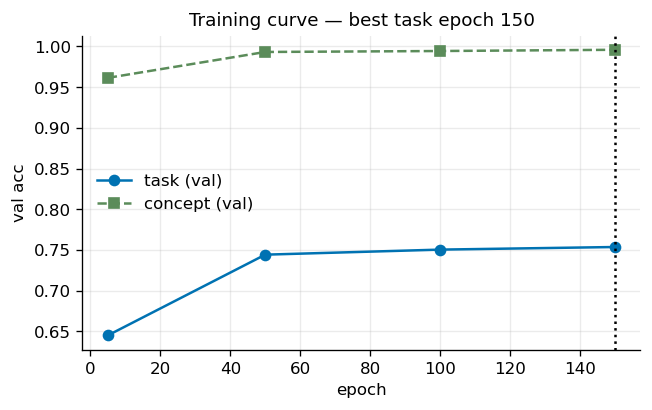

In [2]:
import torch
preds = REPO/"external"/"minimal_cbm"/"results"/"funnybirds-cbm"/"1"/"predictions"
def _acc(pth):
    d = torch.load(pth, map_location="cpu", weights_only=False)
    yp,y=d["y_preds"],d["y"]
    ta=(yp.argmax(-1)==y).float().mean().item() if yp.ndim>1 else (yp==y).float().mean().item()
    ca=None
    if d.get("c_preds") is not None and d.get("c") is not None:
        cp=d["c_preds"]; cp=cp[...,0] if cp.ndim==3 else cp; ca=((cp>=0.5).float()==d["c"]).float().mean().item()
    return ta,ca
fs=sorted(glob.glob(str(preds/"epoch_*.pth")), key=lambda p:int(re.findall(r"epoch_(\d+)",p)[0]))
if not fs: print(f"[pending] no per-epoch predictions in {preds}")
else:
    R=pd.DataFrame([(int(re.findall(r"epoch_(\d+)",f)[0]),*_acc(f)) for f in fs],
                   columns=["epoch","task","concept"]).sort_values("epoch"); best=int(R.loc[R.task.idxmax(),"epoch"])
    display(R.round(4)); fig,ax=plt.subplots(figsize=(6,3.4))
    ax.plot(R.epoch,R.task,"o-",color=CBM_C,label="task (val)")
    if R.concept.notna().any(): ax.plot(R.epoch,R.concept,"s--",color="#5B8C5A",label="concept (val)")
    ax.axvline(best,ls=":",color="k"); ax.set_xlabel("epoch"); ax.set_ylabel("val acc")
    ax.set_title(f"Training curve — best task epoch {best}"); ax.legend()
    drop=R.task.max()-R.task.iloc[-1]
    print("VERDICT:", "plateau -> no overfit" if abs(drop)<0.01 else f"peaks {best} then declines")

**Read this figure:** concept accuracy is near 1 and species accuracy levels near 0.75, so
the model is usable for analysis. With only a few saved epochs, do not infer “no overfit”
from this plot alone; validation loss or denser checkpoints would be needed.


## 2 · What does the model do on ordinary, untouched images?

Choose a source concept that is present and a donor concept that is absent. If the CBM is
well behaved on normal data, the source should be strongly on and the donor strongly off.
This is an important control: otherwise later intervention failures could just reflect a
generally broken concept layer.


,z_src_present,z_donor_absent
part,,
tail,14.895,-35.855
wing,14.253,-22.827
beak,16.775,-17.062
foot,19.265,-18.111
eye,14.469,-21.585


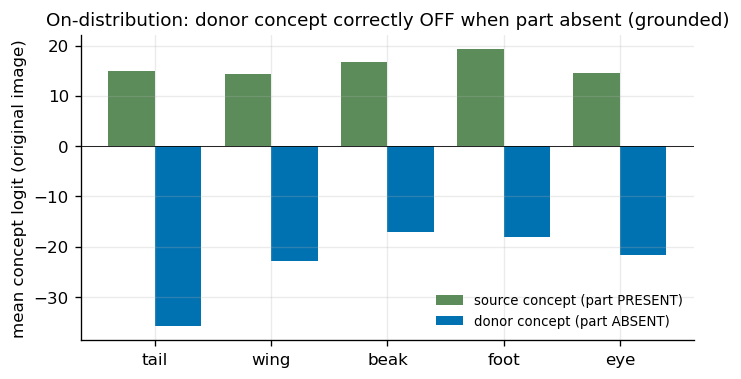

In [7]:
SW = CURATED/"swap"/"funnybirds-cbm-s1.csv"
ORDER=["tail","wing","beak","foot","eye"]
if not need(SW, 'CONFIG_PREFIX=funnybirds-cbm GAMMAS="0" SEEDS="1" sbatch train/renderer_swap.slurm'):
    S=None
else:
    S=pd.read_csv(SW)
    g=S.groupby("part").agg(z_src_present=("z_old_orig","mean"),
                            z_donor_absent=("z_new_orig","mean")).reindex(ORDER)
    display(g.round(3))
    fig,ax=plt.subplots(figsize=(6.6,3.3)); x=np.arange(len(g)); w=0.4
    ax.bar(x-w/2,g.z_src_present,w,color="#5B8C5A",label="source concept (part PRESENT)")
    ax.bar(x+w/2,g.z_donor_absent,w,color=CBM_C,label="donor concept (part ABSENT)")
    ax.axhline(0,color="k",lw=0.5); ax.set_xticks(x); ax.set_xticklabels(g.index)
    ax.set_ylabel("mean concept logit (original image)"); ax.legend(fontsize=8)
    ax.set_title("On-distribution: donor concept correctly OFF when part absent (grounded)")

**Observation:** all parts look normal before intervention. Present concepts are strongly on;
absent alternatives are strongly off. Therefore any later puzzle is specific to a
contradictory image, not a broad failure on the ordinary test distribution.


## 3 · First intervention: remove one part

If a concept reads its own part, removing a visibly present part should reduce that concept.
`retained_frac = P(concept after removal) / P(concept before removal)`.

Two estimates are shown. “All removals” includes cases where the nominal deletion changed
almost no pixels because the part was already hidden. “Visible-only” removes those no-op
cases and is the interpretable estimate.


In [ ]:
G = load_grounding("funnybirds-cbm")
if G is None: print("[pending] bash analysis/grounding_sweep.sh")
else:
    allp = per_part_seedagg(G, visible_only=False)
    visp = per_part_seedagg(G, visible_only=True)
    R = pd.DataFrame({"retained_all":allp["mean"], "retained_visible":visp["mean"],
                      "vis_std":visp["std"]})
    if "changed_frac" in G.columns:
        occ = G[G["changed_frac"]<=EPS]
        R["conf_on_occluded"] = occ.groupby("part").p_intact.mean()
        R["frac_noop"] = G.groupby("part").changed_frac.apply(lambda s:(s<=EPS).mean())
    R = R.sort_values("retained_visible", ascending=False); display(R.round(3))
    print(f"n_seeds = {G.seed.nunique()}  (seeds: {sorted(G.seed.unique())})")
    fig,ax=plt.subplots(figsize=(6.6,3.4)); x=np.arange(len(R)); w=0.4
    ax.bar(x-w/2, R.retained_all, w, color="#9ec9e2", label="all removals (inflated)")
    ax.bar(x+w/2, R.retained_visible, w, yerr=R.vis_std.fillna(0), capsize=3, color=CBM_C, label="visible-only (headline)")
    ax.set_xticks(x); ax.set_xticklabels(R.index, rotation=30, ha="right")
    ax.set_ylabel("retained_frac"); ax.set_ylim(0,1); ax.legend()
    ax.set_title("FunnyBirds · CBM · removed-part concept retention")

**Observation:** tail is unusual, but the correction matters: its estimate falls from about
0.35 to about 0.16 after no-op deletions are removed. This is an anomaly worth investigating,
not yet proof of species lookup. Removal creates an unnatural image and cannot tell us which
wrong concept, if any, replaces the missing evidence.


## 4 · Stronger intervention: replace one part with another valid part

Deletion asks whether a concept turns off. A swap asks the more specific question: does the
concept follow the new visible part? The renderer keeps camera, light, background, and the
rest of the bird fixed.

First inspect example triplets. A bad render or multiple changed parts would invalidate the
causal interpretation.


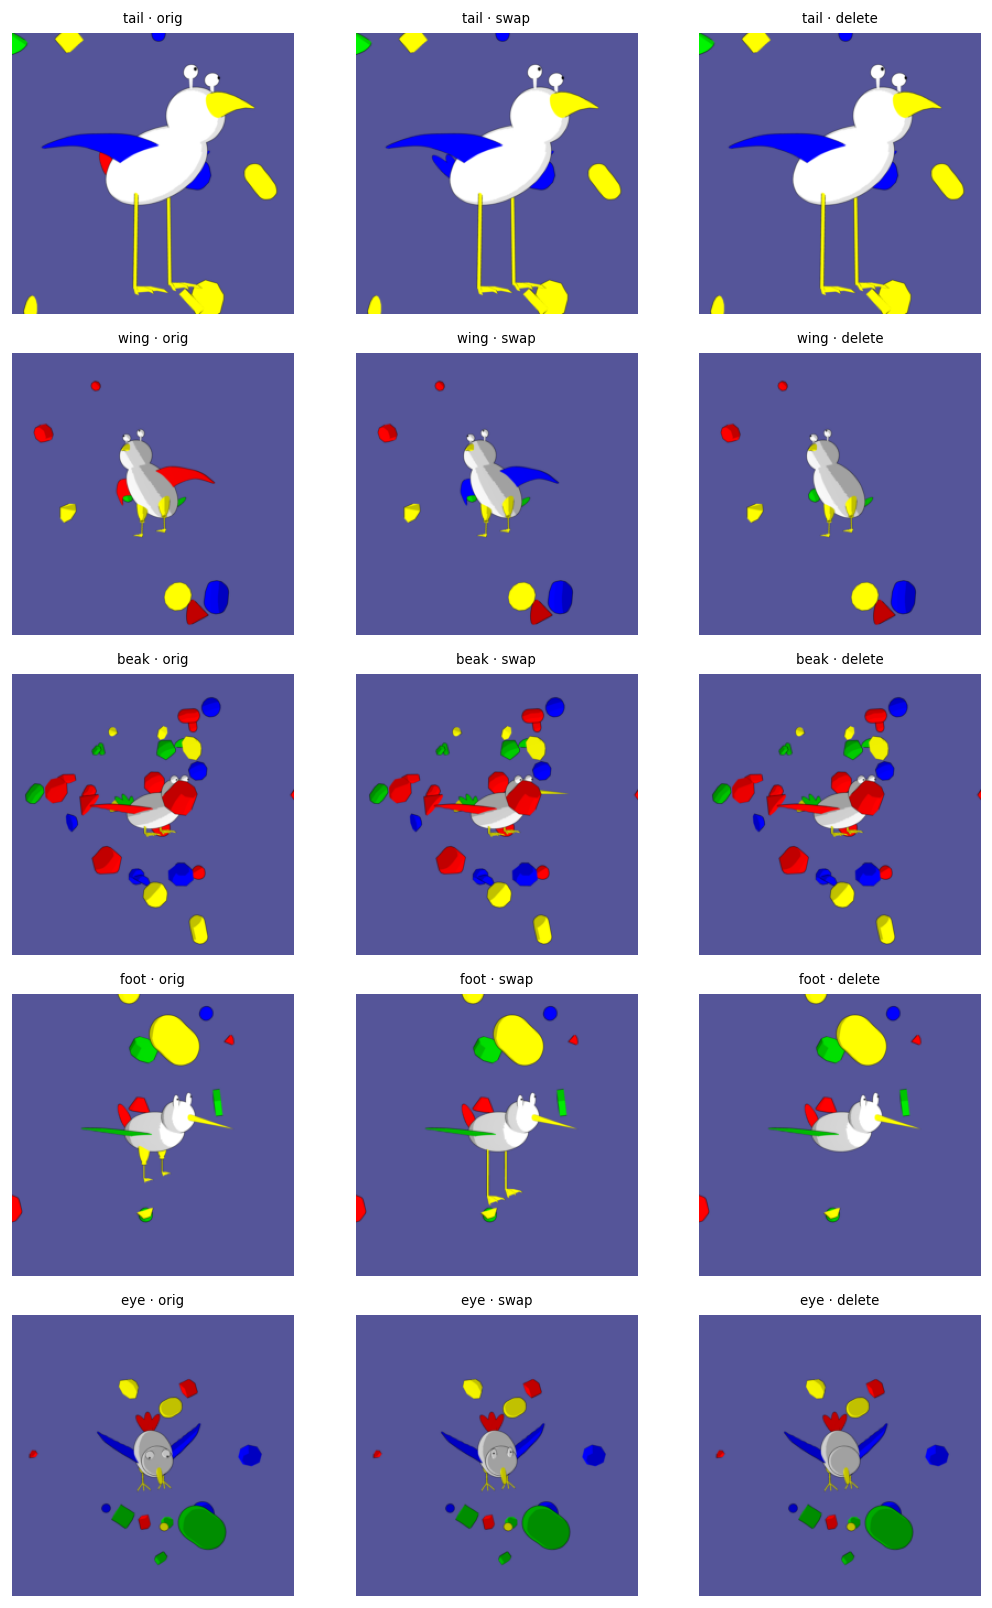

In [10]:
import matplotlib.image as mpimg
exdir=CURATED/"swap"/"examples"; tags=["orig","swap","delete"]
if exdir.exists() and any(exdir.glob("*.png")):
    fig,axes=plt.subplots(len(ORDER),len(tags),figsize=(3*len(tags),2.7*len(ORDER)))
    for r,part in enumerate(ORDER):
        for c,t in enumerate(tags):
            axm=axes[r,c] if len(ORDER)>1 else axes[c]
            fs=sorted(exdir.glob(f"{part}_*_{t}.png"))
            if fs: axm.imshow(mpimg.imread(str(fs[0])))
            axm.set_title(f"{part} · {t}",fontsize=8); axm.axis("off")
    plt.tight_layout()
else:
    need(exdir/"<part>_*_orig.png", 'run train/renderer_swap.slurm (it saves examples first)')

**Check manually:** only the named target part should differ across original, swap, and
deletion. This grid is a spot check, not proof for every generated image; the data builder's
pixel-difference checks remain necessary.


### 4a · Does the new part's concept beat the old part's concept?

For each swap, compare the two relevant logits after the swap:

`margin = donor concept − source concept`.

Positive means the concept layer followed the replacement; negative means it stayed with the
old concept. Both swap directions are reported to catch reversed bookkeeping.


In [ ]:
if S is not None:
    ordf=S.groupby(["part","direction"]).ordering_correct.mean().unstack().reindex(ORDER)
    display(ordf.round(3))
    fig,ax=plt.subplots(figsize=(6.6,3.3)); x=np.arange(len(ordf)); w=0.4
    ax.bar(x-w/2,ordf.get("fwd"),w,color=CBM_C,label="fwd (A's image ← B's part)")
    ax.bar(x+w/2,ordf.get("bwd"),w,color="#D55E00",label="bwd (B's image ← A's part)")
    ax.axhline(1.0,ls=":",color="green",label="grounded (=1)"); ax.axhline(0.5,ls=":",color="gray")
    ax.set_xticks(x); ax.set_xticklabels(ordf.index); ax.set_ylim(0,1.05)
    ax.set_ylabel("ordering_correct (donor concept wins after swap)"); ax.legend(fontsize=8)
    ax.set_title("Renderer-swap z-ordering per part (fwd/bwd)")
    print("~1 = swapped-in part detected (grounded). <1 = anchored to source species = backwash.")
else: print("[pending] swap CSV")

**Observation:** wing and foot usually follow the replacement. Tail usually does not; beak
is near chance and eye is mixed. The two directions agree, which argues against a simple
forward/backward scoring error. Call this a **graded, part-specific swap-following failure**.
It is not tail-only, and it is not yet enough to identify the cause.


In [ ]:
if S is not None:
    PCOL={"tail":"#6a0dad","wing":"#1f77b4","beak":"#8c6d31","foot":"#2ca02c","eye":"#d4a017"}
    order=[p for p in ORDER if (S.part==p).any()]
    data=[S[S.part==p].margin.values for p in order]
    fig,ax=plt.subplots(figsize=(7.8,3.8))
    bp=ax.boxplot(data,showfliers=False,patch_artist=True,medianprops=dict(color="k"),whis=(5,95))
    for patch,p in zip(bp["boxes"],order): patch.set_facecolor(PCOL.get(p,"#888")); patch.set_alpha(0.55)
    ax.axhline(0,color="r",lw=1,ls="--",label="ordering boundary (0)")
    ax.set_xticks(range(1,len(order)+1)); ax.set_xticklabels(order)
    y0,y1=ax.get_ylim()
    for i,p in enumerate(order):
        mp=S[S.part==p].margin
        ax.annotate(f"{100*(mp<=0).mean():.0f}% viol\nn={len(mp)}",(i+1,y1),fontsize=6,ha="center",va="top")
    ax.set_ylabel("z-ordering margin (donor − source)"); ax.legend(fontsize=7)
    ax.set_title("Margin per part (whiskers 5–95%) — box below red = species-anchored (backwash)")
else: print("[pending] swap CSV")

The distribution confirms that the averages are not driven by a few extreme swaps. Tail is
mostly below zero; wing and foot are mostly above. The same original image is reused across
several swaps, so the dots are not independent and density must not be treated as sample size.


### 4b · Coverage and data-integrity table

The original notebook printed many intermediate tables. The useful part was not their volume;
it was checking that every part, direction, species, and variant was actually represented.
Before interpreting a plot, print those counts and missing values.


In [ ]:
if S is not None:
    required=["sid_src","sid_donor","part","var_src","var_donor","z_new","z_old",
              "z_new_orig","z_old_orig","margin","ordering_correct","direction"]
    print("rows:",len(S),"  missing required columns:",[c for c in required if c not in S])
    present=[c for c in required if c in S]
    print("missing values in required fields:",int(S[present].isna().sum().sum()))
    coverage=(S.groupby(["part","direction"])
                .agg(rows=("margin","size"),source_species=("sid_src","nunique"),
                     donor_species=("sid_donor","nunique"),source_variants=("var_src","nunique"),
                     donor_variants=("var_donor","nunique")))
    display(coverage)
    print("Important limitation: the current CSV does not store an original-image ID. "
          "Rows reuse originals, so uncertainty must be grouped by seed/species, not by row.")


### 4c · Did the replacement concept itself move after the swap?

The ordering margin compares the new concept with the old concept. This extra view asks a
simpler question from the original notebooks: how much did the donor concept change relative
to its value on the untouched image? A positive shift means the replacement pixels affected
that concept, even if it still failed to beat the source concept.


In [ ]:
if S is not None and {"z_new","z_new_orig"}.issubset(S.columns):
    d=S.assign(donor_shift=S.z_new-S.z_new_orig)
    order=[p for p in ORDER if (d.part==p).any()]
    vals=[d.loc[d.part==p,"donor_shift"].values for p in order]
    fig,ax=plt.subplots(figsize=(7.5,3.8))
    ax.boxplot(vals,tick_labels=order,showfliers=False,whis=(5,95))
    ax.axhline(0,color="0.35",ls=":")
    ax.set_ylabel("donor concept after swap − before swap")
    ax.set_title("Does the replacement part move its own concept?")
    ax.grid(axis="y",alpha=.2); plt.show()
    display(d.groupby("part").donor_shift.agg(["mean","median","std","size"]).round(3))


This separates “the new concept did not respond” from “it responded, but the old concept stayed
even stronger.” Those are different failure modes and should lead to different follow-ups.


## 5 · Could the new part simply be too small or hidden?

This is the first alternative explanation to test. A failure on a nearly invisible tail is
not evidence that the model ignored clear tail pixels.

Plot swap-following against the visible pixel count of the replacement part. Every bin must
show its row count: a high or low fraction based on a handful of swaps is not stable evidence.


In [ ]:
if S is not None and "pixel_count_cf" in S.columns:
    PCOL={"tail":"#6a0dad","wing":"#1f77b4","beak":"#8c6d31","foot":"#2ca02c","eye":"#d4a017"}
    bins=[0,20,50,100,200,500,10000]
    labels=[f"{bins[i]}–{bins[i+1]}" for i in range(len(bins)-1)]
    d=S.copy()
    d["vis_bin"]=pd.cut(d.pixel_count_cf,bins=bins,labels=labels,right=False)
    tab=d.groupby(["part","vis_bin"],observed=False).ordering_correct.agg(["mean","size"])
    display(tab.rename(columns={"mean":"fraction_correct","size":"n"}).round(3))
    fig,ax=plt.subplots(figsize=(8.5,4.3))
    for p in ORDER:
        q=tab.loc[p]
        ax.plot(range(len(labels)),q["mean"],"o-",label=p,color=PCOL[p])
        for x,(y,n) in enumerate(zip(q["mean"],q["size"])):
            if pd.notna(y): ax.annotate(f"n={int(n)}",(x,y),xytext=(0,6),textcoords="offset points",ha="center",fontsize=7)
    ax.axhline(.5,color="0.45",ls=":",label="half of swaps")
    ax.set(xticks=range(len(labels)),xticklabels=labels,ylim=(0,1.05),
           xlabel="visible pixels in replacement part",ylabel="fraction following replacement")
    ax.legend(ncol=3,fontsize=8); ax.grid(alpha=.2); plt.show()


**How to decide:** if tail reaches foot/wing performance when clearly visible, low test-time
visibility explains the failure. If it improves but remains much lower, visibility explains
only part of it. Do not compare bins without checking their `n` values and variant mix.


,all_swaps,visible_only(>=50px)
part,,
tail,0.366,0.476
wing,0.842,0.844
beak,0.488,0.549
foot,0.893,0.917
eye,0.601,0.661


Rises after filtering -> occlusion. Stays low -> backwash (the real result).


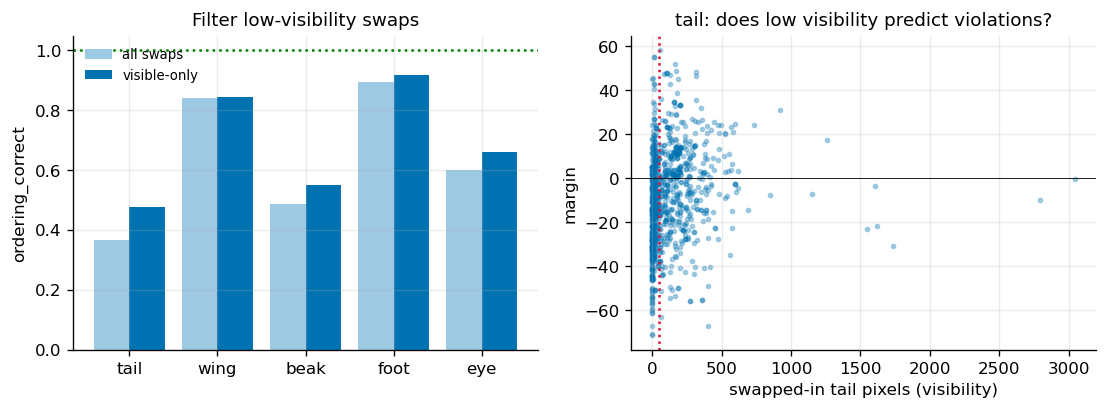

In [13]:
if S is not None and "pixel_count_cf" in S.columns:
    MIN_PX=50
    before=S.groupby("part").ordering_correct.mean()
    after =S[S.pixel_count_cf>=MIN_PX].groupby("part").ordering_correct.mean()
    C=pd.DataFrame({"all_swaps":before,f"visible_only(>={MIN_PX}px)":after}).reindex(ORDER)
    display(C.round(3))
    fig,ax=plt.subplots(1,2,figsize=(11,3.4)); x=np.arange(len(C)); w=0.4
    ax[0].bar(x-w/2,C.iloc[:,0],w,color="#9ec9e2",label="all swaps")
    ax[0].bar(x+w/2,C.iloc[:,1],w,color=CBM_C,label="visible-only")
    ax[0].axhline(1,ls=":",color="green"); ax[0].set_xticks(x); ax[0].set_xticklabels(C.index)
    ax[0].set_ylim(0,1.05); ax[0].set_ylabel("ordering_correct"); ax[0].legend(fontsize=8)
    ax[0].set_title("Filter low-visibility swaps")
    t=S[S.part=="tail"]
    ax[1].scatter(t.pixel_count_cf,t.margin,s=6,alpha=0.3,color=CBM_C)
    ax[1].axhline(0,color="k",lw=0.5); ax[1].axvline(MIN_PX,ls=":",color="crimson")
    ax[1].set_xlabel("swapped-in tail pixels (visibility)"); ax[1].set_ylabel("margin")
    ax[1].set_title("tail: does low visibility predict violations?")
    print("Rises after filtering -> occlusion. Stays low -> backwash (the real result).")
elif S is not None:
    print("[pending] swap CSV lacks pixel_count_cf (run WITHOUT --no-v2)")

**Current observation:** filtering tiny replacement tails improves tail noticeably, so
test-time visibility **does matter**. Tail still remains far below foot and wing, so it is
not the complete explanation.

This does not settle **training-time occlusion**. A model repeatedly trained with a hidden
tail but a species-level tail label may learn to use the rest of the bird; it can then ignore
even a clear tail at test time. The relabeled-training notebook is the direct test of that idea.


## 6 · Could some variants simply be hard to tell apart?

For each part, ask which variant wins after a swap. A good detector makes a bright diagonal.
A bright off-diagonal column means many different replacements collapse onto one default
answer. Counts must accompany rates, and visual similarity remains a possible explanation.


per-part diagonal (fraction correctly attributed): {'tail': 0.273}


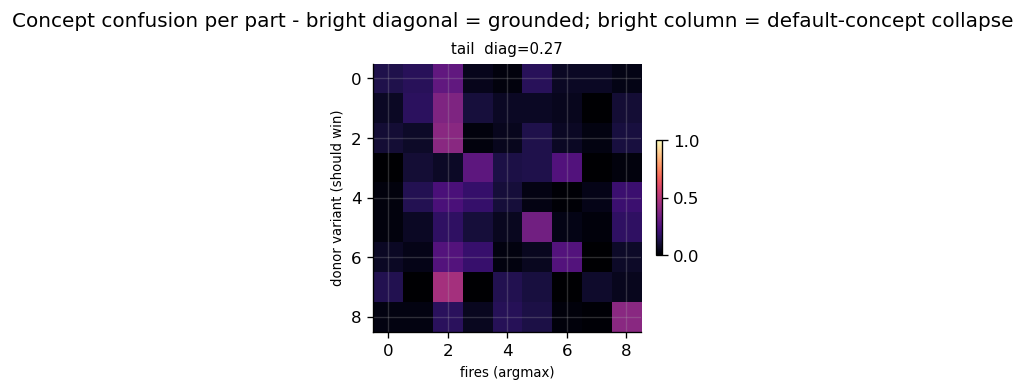

In [14]:
if S is not None:
    # ALL-PART confusion: for each part, which variant's concept fires strongest after a swap.
    # Bright diagonal = grounded (swapped-in variant wins); bright COLUMN = "default concept"
    # collapse. A grounded part (foot) should show a clean diagonal that contrasts the tail.
    have=[p for p in ORDER if any(c.startswith(f"z_cf_{p}_") for c in S.columns)]
    if not have:
        print("[pending] swap CSV has no z_cf_<part>_* columns.")
        print("  re-run with the current driver (logs all parts):")
        print("  CONFIG_PREFIX=funnybirds-cbm SEEDS=1 sbatch train/renderer_swap.slurm")
    else:
        fig,axes=plt.subplots(1,len(have),figsize=(3.1*len(have),3.2))
        if len(have)==1: axes=[axes]
        last=None; diags={}
        for ax,p in zip(axes,have):
            cols=sorted([c for c in S.columns if c.startswith(f"z_cf_{p}_")],
                        key=lambda c:int(c.split("_")[-1]))
            dd=S[S.part==p].dropna(subset=cols)
            if not len(dd): ax.set_title(f"{p} (no data)"); ax.axis("off"); continue
            n=len(cols); predv=dd[cols].values.argmax(1); dv=dd.var_donor.astype(int).values
            M=np.zeros((n,n))
            for a,b in zip(dv,predv):
                if 0<=a<n: M[a,b]+=1
            M=M/M.sum(1,keepdims=True).clip(min=1)
            diags[p]=round(float((predv==dv).mean()),3)
            last=ax.imshow(M,cmap="magma",vmin=0,vmax=1)
            ax.set_title(f"{p}  diag={diags[p]:.2f}",fontsize=9); ax.set_xlabel("fires (argmax)",fontsize=8)
        axes[0].set_ylabel("donor variant (should win)",fontsize=8)
        fig.suptitle("Concept confusion per part - bright diagonal = grounded; bright column = default-concept collapse")
        if last is not None: fig.colorbar(last,ax=axes,fraction=0.02)
        print("per-part diagonal (fraction correctly attributed):", diags)
else: print("[pending] swap CSV")

**Observation:** grounded parts provide a built-in positive control. Tail has a weak diagonal
and several replacements collapse toward the same answer. This rules out a single globally
broken swap pipeline, but it does not yet distinguish species lookup from visually similar
tail shapes. The next useful addition is a small atlas of each tail variant beside this matrix.


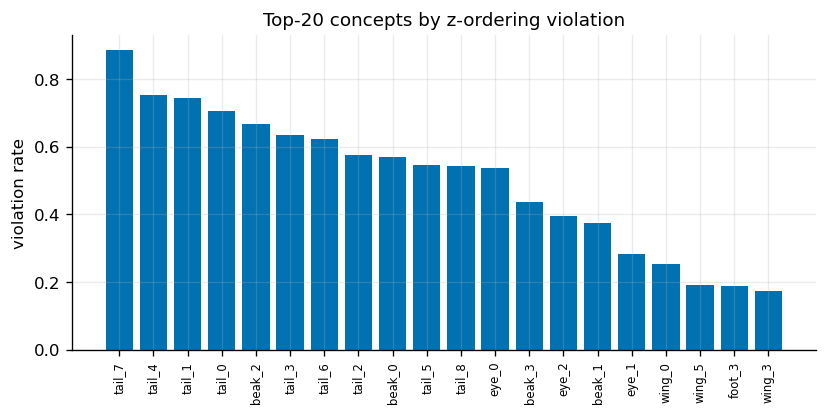

In [16]:
if S is not None:
    vc=S.assign(viol=~S.ordering_correct.astype(bool)).groupby(["part","var_donor"]).viol.mean().sort_values(ascending=False).head(20)
    fig,ax=plt.subplots(figsize=(8,3.4)); ax.bar([f"{p}_{int(v)}" for p,v in vc.index],vc.values,color=CBM_C)
    ax.set_ylabel("violation rate"); ax.set_title("Top-20 concepts by z-ordering violation"); plt.xticks(rotation=90,fontsize=7)
else: print("[pending] swap CSV")

The worst individual slots are mostly tails, with some beaks and eyes. This rejects a single
bad tail index but still leaves frequency, visibility, and visual similarity as explanations.


## 7 · Does the original species still matter after the part is changed?

If the rest of the bird is being used, failure should vary with the source species. But raw
species bars can also reflect unequal counts, tail variants, and visibility. Show counts and
treat this as supporting evidence, not a standalone proof.


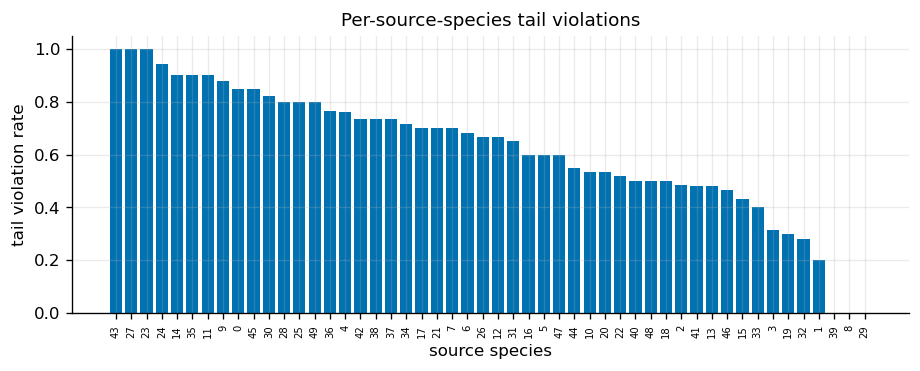

In [17]:
if S is not None:
    d=S[S.part=="tail"].assign(viol=~S[S.part=="tail"].ordering_correct.astype(bool))
    sv=d.groupby("sid_src").viol.mean().sort_values(ascending=False)
    fig,ax=plt.subplots(figsize=(9,3)); ax.bar(sv.index.astype(str),sv.values,color=CBM_C)
    ax.set_xlabel("source species"); ax.set_ylabel("tail violation rate"); ax.set_title("Per-source-species tail violations")
    plt.xticks(rotation=90,fontsize=6)
else: print("[pending] swap CSV")

**Observation:** failure varies greatly by source species, which is consistent with reliance
on the unchanged body. Before calling it decisive, control for donor variant, visible pixels,
and repeated originals; some species may simply supply harder or rarer tail combinations.


In [ ]:
sps = sorted(glob.glob(str(CURATED/"species_probe"/"funnybirds-cbm-s*.json")))
PARTV=None
if not sps: print("[pending] bash analysis/grounding_sweep.sh")
else:
    Ss=[json.loads(Path(p).read_text()) for p in sps]; ch=Ss[0]["chance"]
    zc=np.mean([s["species_from_z"]["acc"] for s in Ss]); cc=np.mean([s["species_from_cpreds"]["acc"] for s in Ss])
    print(f"n_seeds={len(Ss)} | chance={ch:.3f} | species<-z {zc:.3f} | species<-c_preds {cc:.3f}")
    parts=list(Ss[0]["species_from_part_cpreds"].keys())
    PARTV=pd.DataFrame({"species_code":[np.mean([s["species_from_part_cpreds"][p]["acc"] for s in Ss]) for p in parts],
                        "n_variants":[Ss[0]["species_from_part_cpreds"][p]["n_variants"] for p in parts]}, index=parts)
    PARTV=PARTV.sort_values("species_code", ascending=False); display(PARTV.round(3))
    fig,ax=plt.subplots(1,2,figsize=(10,3.2))
    ax[0].bar(["z","c_preds"],[zc,cc],color=CBM_C); ax[0].axhline(ch,ls="--",color="k",label="chance")
    ax[0].set_ylim(0,1); ax[0].set_title("species recoverable from bottleneck"); ax[0].legend()
    ax[1].bar(PARTV.index, PARTV.species_code, color=CBM_C); ax[1].axhline(ch,ls="--",color="k")
    ax[1].set_title("species from EACH part's concepts"); plt.setp(ax[1].get_xticklabels(),rotation=30,ha="right")

The full concept vector predicts species almost perfectly, but no single part group does.
Species information is distributed across the assembled vector. This shows that a species
lookup route is available; it does not prove that a particular tail prediction used it.


## 8 · Does the concept-layer failure change the final species prediction?

Even a real explanation failure may have little effect on the classifier. Plot donor-species
probability against the swap margin, using visibility only as an independent colour and a
binned mean for the trend.


In [ ]:
if S is not None:
    t=S[S.part=="tail"].copy()
    fig,ax=plt.subplots(figsize=(6.4,4))
    # colour by an INDEPENDENT variable (visibility), NOT by the margin's own sign (that
    # would be tautological). The relationship we care about is the binned-mean trend.
    if "pixel_count_cf" in t.columns:
        sc=ax.scatter(t.margin,t.p_cf_donor,s=7,alpha=0.3,
                      c=np.log10(t.pixel_count_cf.clip(lower=1)),cmap="viridis")
        fig.colorbar(sc,label="log10 swapped-in tail pixels")
    else:
        ax.scatter(t.margin,t.p_cf_donor,s=7,alpha=0.3,color="#888")
    t["mb"]=pd.qcut(t.margin,8,duplicates="drop")
    gb=t.groupby("mb",observed=True).agg(mx=("margin","mean"),my=("p_cf_donor","mean"))
    ax.plot(gb.mx,gb.my,"o-",color="crimson",lw=2,label="binned mean (P donor vs margin)")
    ax.axvline(0,color="k",lw=0.5); ax.set_xlabel("z-ordering margin (donor − source)")
    ax.set_ylabel("P(donor species) after swap"); ax.legend(fontsize=8)
    ax.set_title("Downstream: does a larger margin move species probability?")
else: print("[pending] swap CSV")

**Observation:** the average donor-species probability rises only slightly. A few swaps have
large effects, but most do not. The supported harm is therefore unreliable concept reasons,
not a general loss of classification accuracy.


## 9 · Honest conclusion and next experiment

What these runs establish:
1. The CBM looks excellent on ordinary images.
2. Under a controlled part swap, its concepts follow some parts well and others poorly.
3. Test-time visibility explains part, but not all, of the tail gap.
4. Variant difficulty and source-species dependence remain plausible contributors.
5. Final species predictions usually change little.

The word **backwash** is a plausible explanation for the residual failure, supported by the
source-species dependence and the species information available in the concept vector. It is
not uniquely proven by any single graph here. The clean next test is to retrain with
visibility-aware, concept/species-breaking labels and repeat the identical swaps. If grounding
improves while rendering and architecture stay fixed, the original label correlation was a
cause. Notebook `03rl` is reserved for that test.


## Original-notebook provenance

This notebook deliberately reuses the experimental ideas from
`funnybird_notebooks/fb_cbm_renderer_swap_v2.ipynb`, after reviewing all 86 cells:

| Current step | Original inspiration | What changed here |
|---|---|---|
| Render inspection | cells 28–29 and 62–64 | Kept as a validity check, not evidence of the mechanism |
| Two-way swap metric | cells 30–41 | Same core comparison; interpretation starts as “swap-following” |
| Normal-image control | cells 42–45 | Moved before the anomaly so the reader knows the model first looks normal |
| Variant confusion | cells 46–54 | Removed the arbitrary good/bad median split; kept matrices/rankings |
| Source-species breakdown | cells 55–61 | Kept, but explicitly requires counts and confound control |
| Downstream effect | cells 65–68 | Uses a binned mean and an independent visibility colour |
| Visibility analysis | cells 72–84 | Promoted into the main causal-check sequence and now prints bin counts |

Renderer and model-loading cells 0–27 run in the SLURM driver rather than the notebook.
Debug-only tables and outcome-coloured plots were not retained because they either duplicated
later figures or coloured points by the answer being measured.
